In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os

In [ ]:
train_dir = "/content/drive/MyDrive/Fruits/train/train"
test_dir = "/content/drive/MyDrive/Fruits/test/test"

print(train_dir)
print(test_dir)

/content/drive/MyDrive/Fruits/train/train
/content/drive/MyDrive/Fruits/test/test


In [ ]:
img_height = 100
img_width = 100
batch_size = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 16851 files belonging to 33 classes.
Using 13481 files for training.
Found 16851 files belonging to 33 classes.
Using 3370 files for validation.


In [ ]:
class_names = train_dataset.class_names

print(class_names)
print("Total Classes:", len(class_names))

['Apple Braeburn', 'Apple Granny Smith', 'Apricot', 'Avocado', 'Banana', 'Blueberry', 'Cactus fruit', 'Cantaloupe', 'Cherry', 'Clementine', 'Corn', 'Cucumber Ripe', 'Grape Blue', 'Kiwi', 'Lemon', 'Limes', 'Mango', 'Onion White', 'Orange', 'Papaya', 'Passion Fruit', 'Peach', 'Pear', 'Pepper Green', 'Pepper Red', 'Pineapple', 'Plum', 'Pomegranate', 'Potato Red', 'Raspberry', 'Strawberry', 'Tomato', 'Watermelon']
Total Classes: 33


In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(100, 100, 3)),

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(len(class_names), activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 33)             │         4,257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,736,033 (6.62 MB)

 Trainable params: 1,736,033 (6.62 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=7
)

Epoch 1/7
422/422 ━━━━━━━━━━━━━━━━━━━━ 197s 466ms/step - accuracy: 0.9897 - loss: 0.0362 - val_accuracy: 0.9997 - val_loss: 5.3027e-04
Epoch 2/7
422/422 ━━━━━━━━━━━━━━━━━━━━ 202s 467ms/step - accuracy: 0.9916 - loss: 0.0276 - val_accuracy: 1.0000 - val_loss: 5.0621e-05
Epoch 3/7
422/422 ━━━━━━━━━━━━━━━━━━━━ 203s 468ms/step - accuracy: 0.9950 - loss: 0.0154 - val_accuracy: 1.0000 - val_loss: 5.9359e-04
Epoch 4/7
422/422 ━━━━━━━━━━━━━━━━━━━━ 201s 476ms/step - accuracy: 0.9907 - loss: 0.0308 - val_accuracy: 1.0000 - val_loss: 3.0728e-04
Epoch 5/7
422/422 ━━━━━━━━━━━━━━━━━━━━ 186s 438ms/step - accuracy: 0.9942 - loss: 0.0183 - val_accuracy: 1.0000 - val_loss: 2.3976e-05
Epoch 6/7
422/422 ━━━━━━━━━━━━━━━━━━━━ 207s 450ms/step - accuracy: 0.9975 - loss: 0.0068 - val_accuracy: 1.0000 - val_loss: 1.3173e-04
Epoch 7/7
422/422 ━━━━━━━━━━━━━━━━━━━━ 211s 472ms/step - accuracy: 0.9939 - loss: 0.0245 - val_accuracy: 0.9997 - val_loss: 9.8741e-04


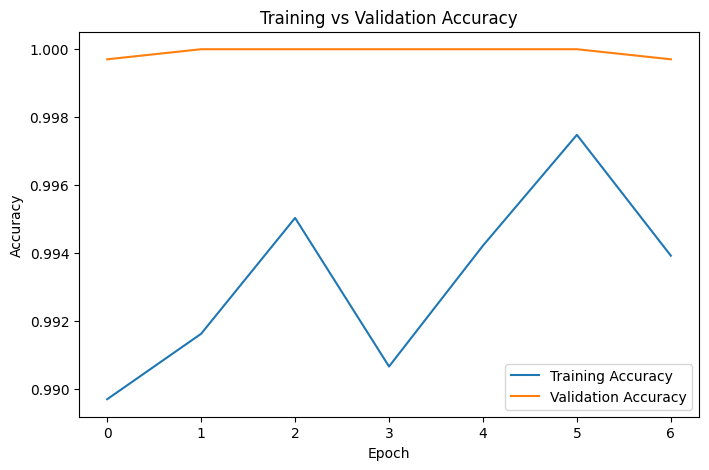

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

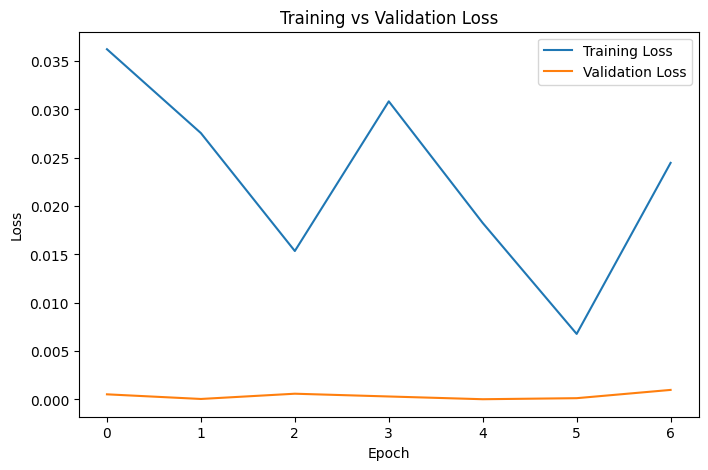

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [ ]:
loss, accuracy = model.evaluate(validation_dataset)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

106/106 ━━━━━━━━━━━━━━━━━━━━ 16s 150ms/step - accuracy: 0.9997 - loss: 9.8741e-04
Validation Loss: 0.0009874057723209262
Validation Accuracy: 0.9997032880783081


In [ ]:
model.save("/content/drive/MyDrive/Fruit_Classification_CNN.keras")

In [ ]:
model.save("/content/drive/MyDrive/Fruit_Classification_CNN.keras")

In [ ]:
import os

print(os.path.exists("/content/drive/MyDrive/Fruit_Classification_CNN.keras"))

True
